In [242]:
#import packages
import h5py 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [225]:
#Loading the input data
hdf = h5py.File('data2.h5', 'r') 
ls = list(hdf.keys())
print(ls)
X_train = np.array(hdf['trainx'])
Y_train = np.array(hdf['traind'])
X_test  = np.array(hdf['testx'])
Y_test   = np.array(hdf['testd'])
X_val  = np.array(hdf['valx'])
Y_val  = np.array(hdf['vald'])
words = np.array(hdf['words'])
hdf.close()

vocab_size = 250
X_train =  X_train - 1
Y_train =  Y_train - 1
X_test  =  X_test - 1
Y_test  =  Y_test -1
X_val   =  X_val - 1
Y_val   =  Y_val -1



['testd', 'testx', 'traind', 'trainx', 'vald', 'valx', 'words']


In [226]:
def one_hot_x(X, vocab_size):
    output = np.zeros((X.shape[0], X.shape[1], vocab_size))
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            index = X[i,j] 
            output[i,j,index] = 1
    return output

def one_hot_y(Y, vocab_size):
    output = np.zeros((Y.shape[0], vocab_size))
    for i in range(Y.shape[0]):
            index = Y[i]
            output[i,index] = 1
    return output

In [227]:
X_train_onehot = one_hot_x(X_train,vocab_size)
Y_train_onehot = one_hot_y(Y_train,vocab_size)
X_test_onehot  = one_hot_x(X_test,vocab_size)
Y_test_onehot   =one_hot_y(X_test,vocab_size)
X_val_onehot  = one_hot_x(X_val,vocab_size)
Y_val_onehot  = one_hot_y(X_val,vocab_size)



In [228]:
#parameters
vocab_size = 250
word_embeddings_size = [32,16,8]
hidden_sizes = [256, 128, 64]
learning_rate = 0.15
momentum_rate= 0.85
max_epochs = 50

i = 0 #to be varied
embedding_size =  word_embeddings_size[i]
hidden_size = hidden_sizes[i]
mini_batch_size  = 200

In [229]:
# Initialize weights and biases
def parameters_initialization(vocab_size,embedding_size,hidden_size):
    EW = np.random.normal(0,0.01,(vocab_size, embedding_size)) #embeddings weights
    W1 = np.random.normal(0,0.01,(embedding_size*3, hidden_size))#hidden weights
    W2 = np.random.normal(0,0.01,(hidden_size, vocab_size)) #output weights
    b1 = np.zeros((1, hidden_size)) #hidden bias
    b2 = np.zeros((1, vocab_size))#output bias

    return {'EW':EW, 'W1':W1, 'W2':W2 , 'b1':b1, 'b2':b2}

def velocity_initialization(parameters):
    Vds = {key: 0 for key in parameters.keys()}
    return Vds

In [230]:
#Activation functions
def sigmoid(z):
    return 1/(1+np.exp(-z))

def softmax(a):
    a_scores = np.exp(a)
    return a_scores/np.sum(a_scores, axis=1, keepdims=True)

#derivatives of activations

def sigmoid_derivative(z):
    return sigmoid(z)*(1-sigmoid(z))


In [231]:
def forward_prop(X_batch,parameters):
        #forward propagation
        embeddings_weights = parameters['EW']
        hidden_weights =  parameters['W1']
        output_weights =  parameters['W2']
        hidden_bias =  parameters['b1']
        output_bias = parameters['b2']

        E = np.dot(X_batch,embeddings_weights)
        E  = E.reshape((len(X_batch), -1))
        embedding_matrix  = E
        #hidden
        Z1 = np.dot(E,hidden_weights) + hidden_bias
        A1 = sigmoid(Z1)
        #output
        Z2 = np.dot(A1,output_weights)+output_bias
        A2 = softmax(Z2)

        cache = {'embedding_matrix': embedding_matrix, 'Z1': Z1, 'A1':A1, 'Z2':Z2, 'A2': A2}
        return A2, cache
    
def crossentropycost(Y_pred, Y_batch):
        cost = -np.sum(Y_batch*np.log(Y_pred),axis=1)
        return np.mean(cost)

def back_prop(X_batch, Y_batch,Y_predictions,cache, parameters):
        
        embedding_matrix = cache['embedding_matrix']
        A1 = cache['A1']
        Z1 = cache['Z1']

        W2 = parameters['W2']
        W1 = parameters['W1']

        dZ2 = Y_predictions - Y_batch
        dW2 = np.dot(A1.T,dZ2)/Y_batch.shape[0]
        db2 = np.sum(dZ2, axis = 0, keepdims= True)/Y_batch.shape[0]

        dZ1  = np.dot(dZ2, W2.T)*sigmoid_derivative(Z1)
        dW1 =  np.dot(embedding_matrix.T,dZ1)/Y_batch.shape[0]
        db1 =  np.sum(dZ1, axis = 0, keepdims= True)/Y_batch.shape[0]


        dE =  np.dot(dZ1, W1.T)
        dE = np.reshape(dE, (Y_batch.shape[0], 3,embedding_size))
       
        temp = 0
        for i in range(3):
                x_ind = X_batch[:, i]
                temp  += np.dot(x_ind.T, dE[:,i])
        temp = temp/3
        dEW  = temp/Y_batch.shape[0]
        

        grads = {'dEW':dEW, 'dW1':dW1, 'dW2':dW2 , 'db1':db1, 'db2':db2}
        return grads


def update_parameters(parameters, gradients, learning_rate, momentum_rate,Vds):
        for key in parameters.keys():
                Vd = Vds[key]
                gradient = gradients['d'+key]
                Vds[key] = momentum_rate*Vd +(1-momentum_rate)*gradient
                parameters[key] -= learning_rate*Vds[key]
                # print(parameters['EW'])
        return parameters, Vds




In [232]:
#Train Model
def train_model(X_train_onehot,Y_train_onehot,learning_rate,momentum_rate, max_epochs,embedding_size,hidden_size):
        
    parameters = parameters_initialization(vocab_size,embedding_size,hidden_size)
    Vds = velocity_initialization(parameters)
        # EW = parameters['EW']
        # W1 =  parameters['W1']
        # W2 =  parameters['W2']
        # b1 =  parameters['b1']
        # b2 = parameters['b2']
    cost_list = []
    val_cost_list = []
    for epoch in range(max_epochs):
        # print(f"Epoch = {epoch}")

        #shuffle data for SGD
        indices = np.random.permutation(X_train_onehot.shape[0])
        X_train_onehot_shuffled = X_train_onehot[indices]
        Y_train_onehot_shuffled = Y_train_onehot[indices]
        cost_batch = []
        for i in range(0,X_train_onehot.shape[0], mini_batch_size):
            X_batch = X_train_onehot_shuffled[i:i+mini_batch_size]
            Y_batch = Y_train_onehot_shuffled[i:i+mini_batch_size]
            
            # print(Vds['b2'])
            A2, cache = forward_prop(X_batch,parameters)

            cost = crossentropycost(A2, Y_batch)
            cost_batch .append(cost)

            grads = back_prop(X_batch, Y_batch,A2,cache, parameters)

            parameters, Vds = update_parameters(parameters, grads, learning_rate, momentum_rate,Vds)
            
        # print(f"Cost after {epoch}th epoch = {cost}")
        cost_list.append(np.mean(cost_batch))
        A2_val, cache_val = forward_prop(X_val_onehot,parameters)
        val_cost = crossentropycost(A2_val, Y_val_onehot)
        val_cost_list.append(val_cost)
    return (parameters,cost_list,val_cost_list)
       


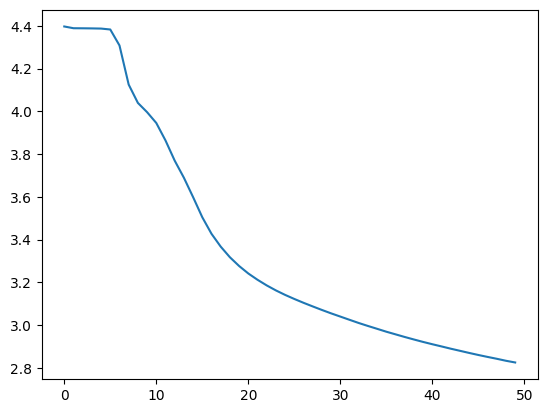

In [233]:
i = 0 # (D,P) = (32,256)
embedding_size =  word_embeddings_size[i] # D =32
hidden_size = hidden_sizes[i] #P = 256
parameters,cost,val_cost = train_model(X_train_onehot,Y_train_onehot,learning_rate,momentum_rate, max_epochs,embedding_size,hidden_size)
# plt.plot(range(10),val_cost[:10])
# plt.plot(range(50),np.array(cost))


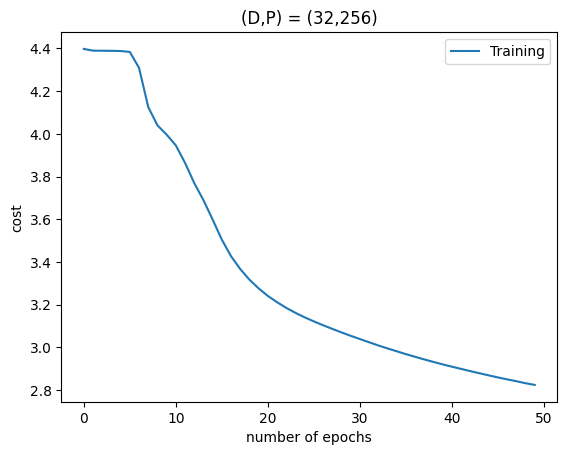

In [234]:
plt.title('(D,P) = (32,256)')
plt.plot(range(50),np.array(cost),label='Training')
plt.xlabel('number of epochs')
plt.ylabel('cost')
plt.legend()


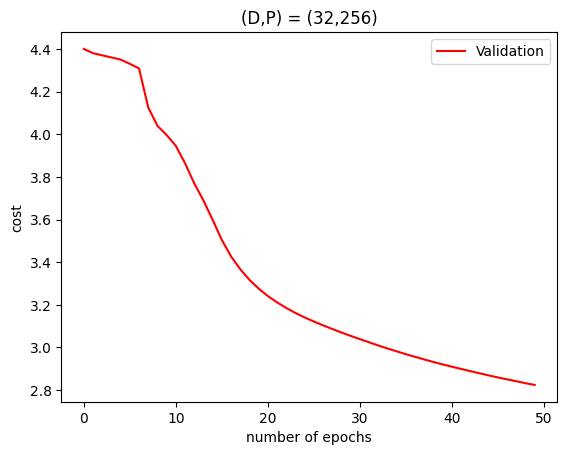

In [273]:
plt.title('(D,P) = (32,256)')
# plt.plot(range(50),np.array(cost),label='Validation')
plt.xlabel('number of epochs')
plt.ylabel('cost')
plt.legend()


In [291]:
#4th word prediction
model1  ={}
for _ in range(5):
    number = np.random.randint(1,X_test.shape[0])
    Sentence = (words[X_test[number][0]].decode('UTF-8') +" "+ 
                words[X_test[number][1]].decode('UTF-8') + " "+ 
                words[X_test[number][2]].decode('UTF-8') + " "+ "'"+
                words[Y_test[number]].decode('UTF-8')+"'" )
    A2, cache = forward_prop(X_test_onehot[number].reshape((1, 3, 250)),parameters)
    result = tuple((x.decode('UTF-8'), list(y*100)) for x, y in zip(tuple(words), tuple(A2.T)))
    a = sorted(result, key= lambda result : result[1], reverse=True)
    for_append = []
    for i in range(10):
        for_append.append(a[i])
    model1[Sentence] = for_append

pd.DataFrame(model1)

,what is going 'on',want us to 'do',can even be '.','s new business '.',over you all 'the'
0,"(on, [59.956456954291006])","(do, [20.07566041009546])","(the, [8.982820145984578])","(., [51.975984073458214])","(., [28.446173985669187])"
1,"(to, [15.851324050466381])","(be, [9.956639706266756])","(there, [6.306857604414567])","(?, [13.53965245156101])","(the, [12.25583345254293])"
2,"(?, [5.864055213132724])","(go, [9.555391770081174])","(here, [4.905174300180018])","(,, [12.8663220527732])","(right, [7.111252502834967])"
3,"(for, [2.731954533543412])","(get, [6.406472729629038])","(out, [4.3585204591497435])","(for, [2.0966844068286186])","(,, [5.151700278789688])"
4,"(up, [1.5417190857554168])","(say, [5.57407273861462])","(?, [4.213279203131225])","(and, [1.811039359624162])","(?, [2.855404710574873])"
5,"(from, [0.847565213351666])","(know, [4.332975951529523])","(right, [3.9151959630140123])","(now, [1.412609792619809])","(there, [2.277766873817099])"
6,"(about, [0.8367514877640227])","(see, [3.9058265722258447])","(that, [3.7452650999311237])","(to, [0.912312535564016])","(have, [1.8263975855626386])"
7,"(out, [0.8113512619673515])","(play, [3.873601502893519])","(., [3.6906854930167023])","(here, [0.9010120172018407])","(like, [1.802106998149034])"
8,"(than, [0.8048475146555153])","(come, [3.66036838785219])","(going, [2.723638281250429])","(in, [0.7930039249582667])","(here, [1.7286920707913895])"
9,"(., [0.7844340581601094])","(work, [3.0844424091936524])","(in, [2.5488428236762166])","(with, [0.7144824857220412])","(and, [1.6766614783186873])"


In [236]:
i = 1 #(D,P) = (16,128)
embedding_size =  word_embeddings_size[i] # D =16
hidden_size = hidden_sizes[i] #P = 128
parameters1,cost1,val_cost1 = train_model(X_train_onehot,Y_train_onehot,learning_rate,momentum_rate, max_epochs,embedding_size,hidden_size)
# plt.plot(range(10),val_cost[:10])
# plt.plot(range(50),np.array(cost))

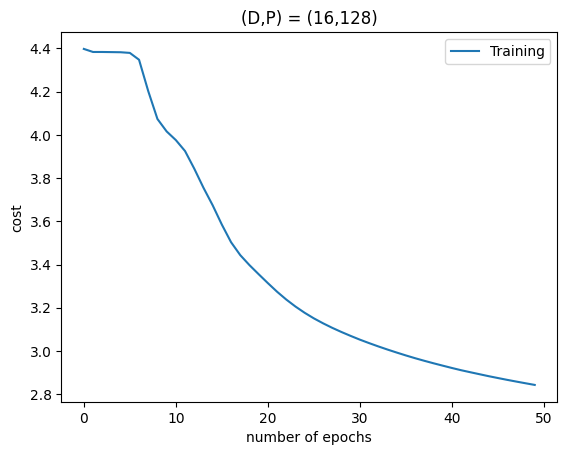

In [237]:
plt.title('(D,P) = (16,128)')
plt.plot(range(50),np.array(cost1),label='Training')
plt.xlabel('number of epochs')
plt.ylabel('cost')
plt.legend()

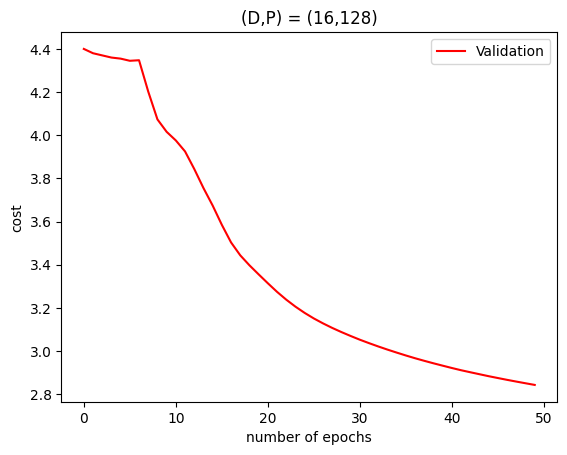

In [286]:
plt.title('(D,P) = (16,128)')
# plt.plot(range(50),np.array(cost1),label='Validation',color='r')
plt.xlabel('number of epochs')
plt.ylabel('cost')
plt.legend()

In [296]:
#4th word prediction
model2  ={}
for _ in range(5):
    number = np.random.randint(1,X_test.shape[0])
    Sentence = (words[X_test[number][0]].decode('UTF-8') +" "+ 
                words[X_test[number][1]].decode('UTF-8') + " "+ 
                words[X_test[number][2]].decode('UTF-8') + " "+ "'"+
                words[Y_test[number]].decode('UTF-8')+"'" )
    A2, cache = forward_prop(X_test_onehot[number].reshape((1, 3, 250)),parameters1)
    result = tuple((x.decode('UTF-8'), list(y*100)) for x, y in zip(tuple(words), tuple(A2.T)))
    a = sorted(result, key= lambda result : result[1], reverse=True)
    for_append = []
    for i in range(10):
        for_append.append(a[i])
    model2[Sentence] = for_append
model2

pd.DataFrame(model2)

,to do that 'this',that 's too 'big',your own life '.',i want to 'do',women see women '.'
0,"(., [53.9759095181359])","(much, [38.4655371606415])","(., [71.03579475255663])","(do, [16.510731464769034])","(., [46.01781309259809])"
1,"(,, [10.19286685678475])","(many, [11.381008355450572])","(,, [11.917573490211495])","(be, [13.660946377578592])","(?, [17.457125731687782])"
2,"(?, [9.719864469020632])","(good, [10.25023593444657])","(?, [7.7200721495903])","(go, [11.789713354833053])","(,, [11.124101584141224])"
3,"(right, [1.7337499213497247])","(big, [9.329148090718062])","(and, [1.2111451229479866])","(get, [8.119418058076706])","(and, [2.464905200829935])"
4,"(now, [1.5493899008077066])","(long, [5.913099177637767])","(is, [0.9218012983302619])","(know, [7.766688909560528])","(to, [1.3080979433608715])"
5,"(all, [1.329845446587386])","(., [2.015921948676207])","(for, [0.7887979270251413])","(see, [6.717090729928158])","(in, [1.165004971282278])"
6,"(for, [1.0984301693174956])","(old, [2.0075498316208074])","(now, [0.5444656981853013])","(play, [5.331210971361513])","(all, [1.1446889535517144])"
7,"(at, [0.7597341365285041])","(new, [1.9450924429808545])","(with, [0.48056651211483453])","(have, [4.561270349743656])","(now, [1.1015521933325738])"
8,"(the, [0.7144352817600766])","(?, [1.847679934687366])","(in, [0.4503038651660447])","(think, [3.9830518024872705])","(at, [0.9324518413057105])"
9,"(that, [0.5996444993067334])","(little, [1.7666893424153074])","(or, [0.43356883207032393])","(come, [3.494358746313587])","(that, [0.9276261282097018])"


In [239]:
i = 2 #(D,P) = (8,64)
embedding_size =  word_embeddings_size[i] # D =8
hidden_size = hidden_sizes[i] #P = 64
parameters2,cost2,val_cost2 = train_model(X_train_onehot,Y_train_onehot,learning_rate,momentum_rate, max_epochs,embedding_size,hidden_size)
# plt.plot(range(10),val_cost[:10])
# plt.plot(range(50),np.array(cost))

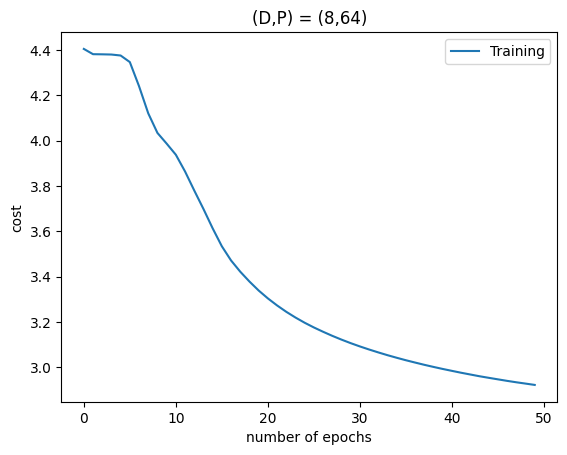

In [240]:
plt.title('(D,P) = (8,64)')
plt.plot(range(50),np.array(cost2),label='Training')
plt.xlabel('number of epochs')
plt.ylabel('cost')
plt.legend()


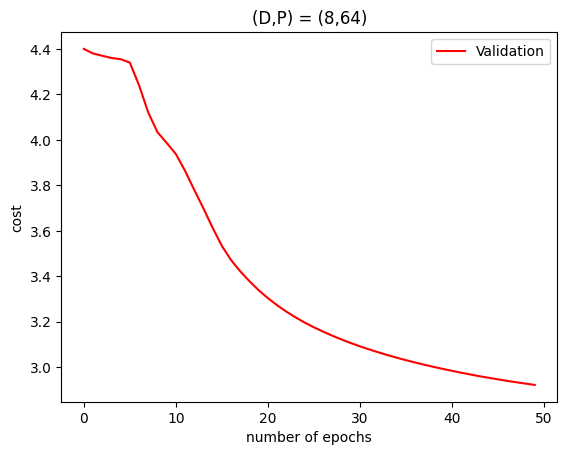

In [289]:
plt.title('(D,P) = (8,64)')
# plt.plot(range(50),np.array(cost2),label='Validation',color='r')
plt.xlabel('number of epochs')
plt.ylabel('cost')
plt.legend()

In [261]:
#4th word prediction
model3  ={}
for _ in range(5):
    number = np.random.randint(1,X_test.shape[0])
    Sentence = (words[X_test[number][0]].decode('UTF-8') +" "+ 
                words[X_test[number][1]].decode('UTF-8') + " "+ 
                words[X_test[number][2]].decode('UTF-8') + " "+"'"+
                words[Y_test[number]].decode('UTF-8')+"'")
    A2, cache = forward_prop(X_test_onehot[number].reshape((1, 3, 250)),parameters2)
    result = tuple((x.decode('UTF-8'), list(y*100)) for x, y in zip(tuple(words), tuple(A2.T)))
    a = sorted(result, key= lambda result : result[1], reverse=True)
    for_append = []
    for i in range(10):
        for_append.append(a[i])
    model3[Sentence] = for_append
model3
pd.DataFrame(model3)

,it 's like 'that',can this last '?',and i think 'that',it is is 'where',for each other '.'
0,"(it, [7.948737689340595])","(year, [17.207014134322932])","(it, [14.678520956858671])","(the, [9.603406122060736])","(., [51.206310263323275])"
1,"(., [7.70320432043828])","(?, [13.491690948959395])","(., [7.314596415223643])","(., [7.2928206937266635])","(,, [8.935815265038537])"
2,"(a, [7.079069869248729])","(., [8.005724766635756])","(,, [7.304337361011824])","(a, [6.797941871509307])","(?, [4.747688200095642])"
3,"(that, [6.50527375041708])","(way, [6.742238544112436])","(i, [6.964260699370138])","(all, [5.793826471081644])","(way, [3.8682711785401356])"
4,"(you, [5.788000514989595])","(time, [6.090423220258291])","(we, [6.880006456737554])","(there, [5.655021385968857])","(year, [2.571038757053733])"
5,"(,, [4.753477173638755])","(week, [4.794646710822172])","(they, [5.674705910389594])","(going, [3.6756153240824743])","(time, [2.4789899472813315])"
6,"(to, [4.046494027622618])","(day, [3.812613833360824])","(he, [5.2508143314092806])","(?, [3.231286351931601])","(team, [2.34909191775581])"
7,"(the, [3.975280279732557])","(years, [2.5406159442778535])","(of, [5.055761628358062])","(here, [2.545413581289095])","(day, [1.5985320478046474])"
8,"(me, [3.597986094021616])","(,, [2.3002628236434903])","(you, [4.493772573530936])","(over, [2.265106612286536])","(game, [1.5521984928804173])"
9,"(?, [3.1462051778550193])","(long, [2.151716551876202])","(about, [3.792194980274103])","(good, [2.213270825625278])","(week, [1.1335521522116607])"
